# Exploratory Data Analysis: Predictive Sales

## Goal
Identify **non-obvious patterns** in the sales data that can inform our modeling strategy. We are looking for the "feel" of the data - what makes a deal close?

## Key Questions
1. **Price Sensitivity**: Do deep discounts lead to wins, or are they a sign of desperation?
2. **Seasonality**: Is there a "best time" to engage?
3. **Agent Performance**: What distinguishes top performers?
4. **Sector/Product Fit**: Where do we have the strongest competitive advantage?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Load Processed Data
try:
    df = pd.read_csv("../data/processed/processed_sales_data.csv")
    print("Data loaded successfully.")
except FileNotFoundError:
    df = pd.read_csv("data/processed/processed_sales_data.csv")
    print("Data loaded from alternate path.")

df.head()

Data loaded successfully.


,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,target,sector,...,manager,regional_office,deal_duration_days,log_close_value,log_revenue,log_employees,engage_year,engage_month,close_year,close_month
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,1,retail,...,Dustin Brinkmann,Central,132,6.961296,6.578723,7.803435,2016,10,2017,3
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0,1,medical,...,Melvin Marxen,Central,137,8.415160,8.064397,8.420903,2016,10,2017,3
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,1,retail,...,Melvin Marxen,Central,133,3.931826,6.578723,7.803435,2016,10,2017,3
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,1,software,...,Dustin Brinkmann,Central,135,6.378426,7.906879,7.879291,2016,10,2017,3
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,1,services,...,Summer Sewald,West,128,6.249975,6.676403,7.170120,2016,10,2017,3


## 1. Target Variable: Deal Stage (Win/Loss)
Let's see the baseline win rate.

Overall Win Rate: 63.2%


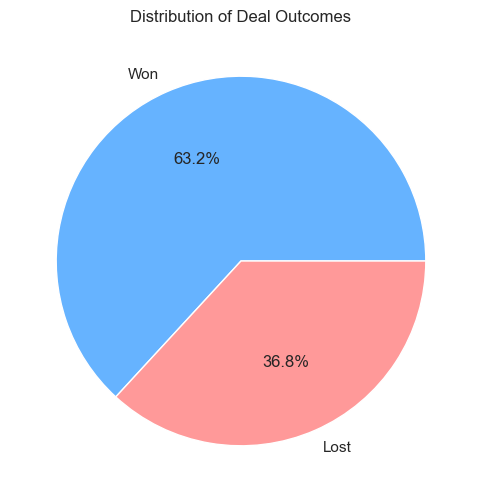

In [2]:
win_rate = df['target'].mean()
print(f"Overall Win Rate: {win_rate:.1%}")

plt.figure(figsize=(6, 6))
df['deal_stage'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title("Distribution of Deal Outcomes")
plt.show()

## 2. Sector and Product Analysis
Which sectors are we strongest in? Which products sell best?

/var/folders/52/nxdkt68n6wgd1y78q3nlxd_80000gn/T/ipykernel_5116/1911180478.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sector_win.index, y=sector_win.values, ax=axes[0], palette="Blues_d")
/var/folders/52/nxdkt68n6wgd1y78q3nlxd_80000gn/T/ipykernel_5116/1911180478.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prod_win.index, y=prod_win.values, ax=axes[1], palette="Greens_d")


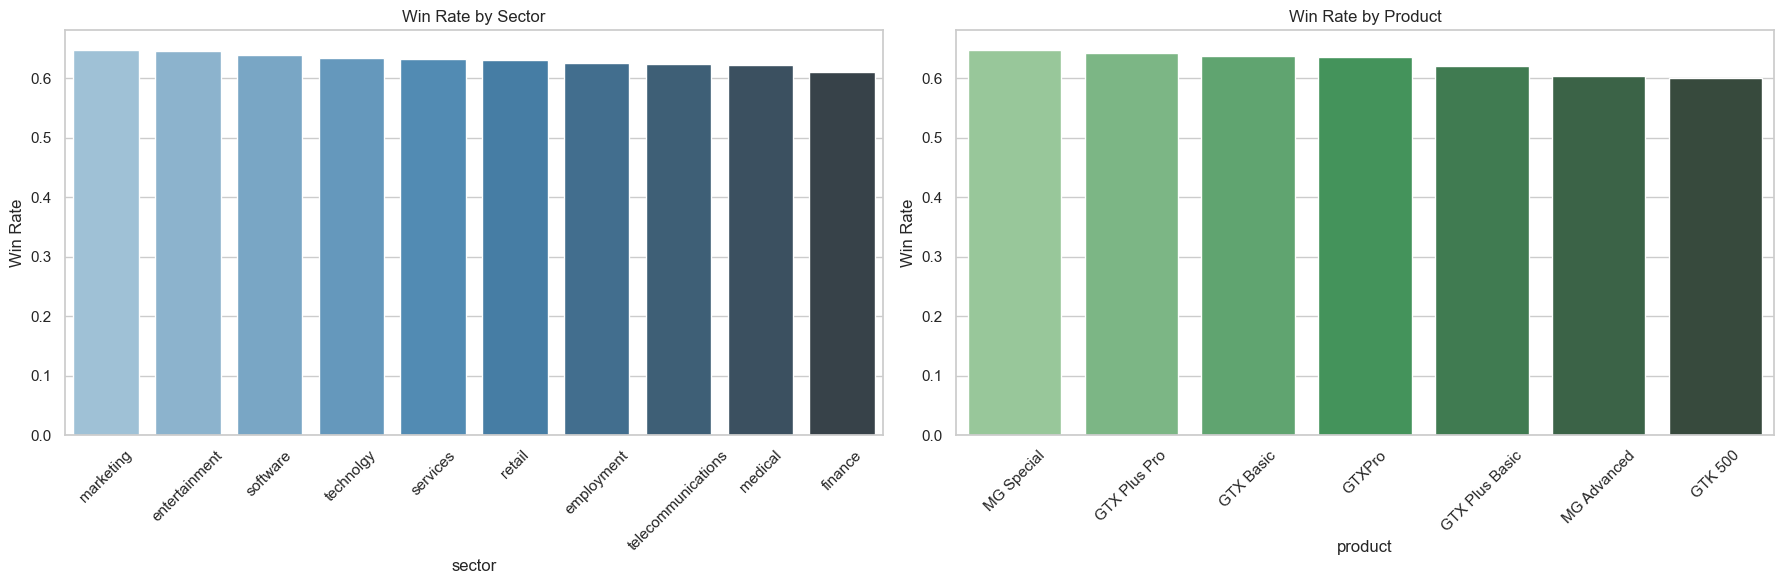

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Sector Win Rates
sector_win = df.groupby('sector')['target'].mean().sort_values(ascending=False)
sns.barplot(x=sector_win.index, y=sector_win.values, ax=axes[0], palette="Blues_d")
axes[0].set_title("Win Rate by Sector")
axes[0].set_ylabel("Win Rate")
axes[0].tick_params(axis='x', rotation=45)

# Product Win Rates
prod_win = df.groupby('product')['target'].mean().sort_values(ascending=False)
sns.barplot(x=prod_win.index, y=prod_win.values, ax=axes[1], palette="Greens_d")
axes[1].set_title("Win Rate by Product")
axes[1].set_ylabel("Win Rate")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. The "Feel" of the Data: Discounting Strategy
**Hypothesis**: Lowering the price (deep discounts) increases the probability of winning.
**Analysis**: Compare `sales_price` (Suggested) vs `close_value` (Actual).

Mean Close Value for Lost Deals: 0.0


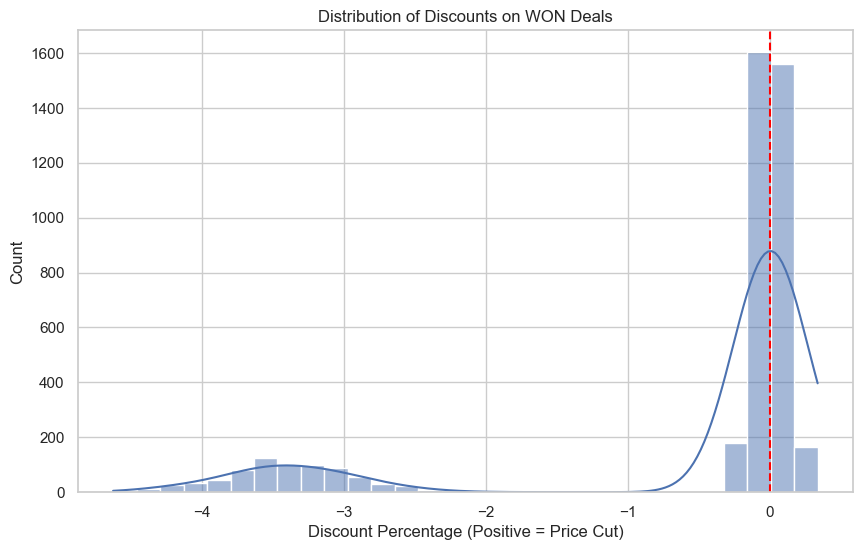

Average Discount on Won Deals: -58.0%


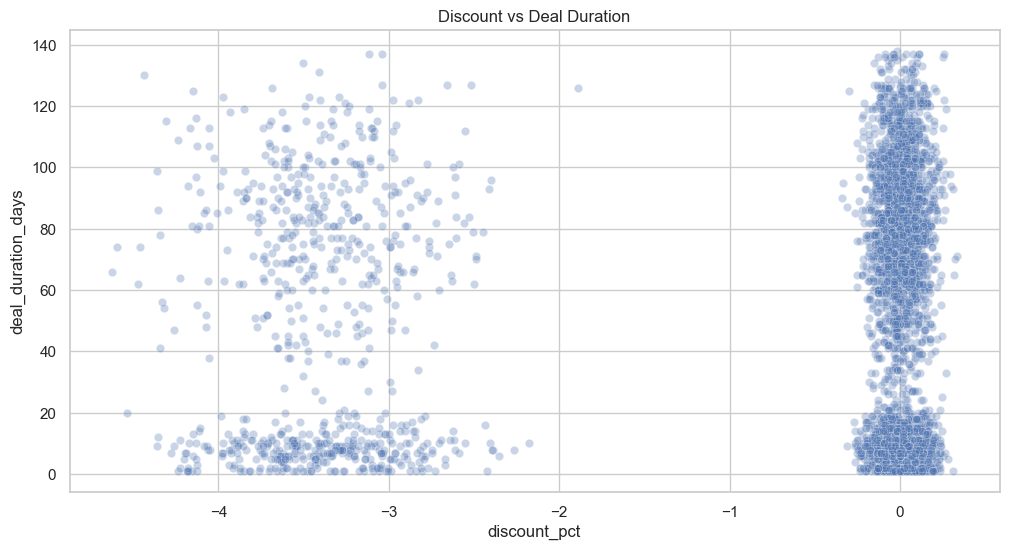

In [4]:
# Calculate Discount Percentage
# Note: close_value might be lower than sales_price.
# We treat 0 close_value as 'Lost' (which they are), but valid 'Won' deals should have non-zero.
# Let's filter for where we have valid comparisons (Won deals mainly, or non-zero close values)
# Actually, for lost deals in this dataset, close_value is 0?
# Let's check the data dictionary or just inspect.
# If close_value is 0 for Lost, we can't calculate discount for Lost. 
# So we can only analyze discount for WON deals to see if they were heavily discounted.
# OR we can assume 'sales_price' was the offer.

# Let's see close_value for Lost deals
print("Mean Close Value for Lost Deals:", df[df['target']==0]['close_value'].mean())

# Analysis:
# Since Lost deals have 0 close value, we can't see the "offered" price that failed.
# However, we CAN see if WON deals tend to be those with high discounts from the 'sales_price'.

won_deals = df[df['target'] == 1].copy()
won_deals['discount_pct'] = (won_deals['sales_price'] - won_deals['close_value']) / won_deals['sales_price']

plt.figure(figsize=(10, 6))
sns.histplot(won_deals['discount_pct'], bins=30, kde=True)
plt.title("Distribution of Discounts on WON Deals")
plt.xlabel("Discount Percentage (Positive = Price Cut)")
plt.axvline(0, color='red', linestyle='--')
plt.show()

print(f"Average Discount on Won Deals: {won_deals['discount_pct'].mean():.1%}")

# Does higher discount correlate with shorter deal duration?
sns.scatterplot(data=won_deals, x='discount_pct', y='deal_duration_days', alpha=0.3)
plt.title("Discount vs Deal Duration")
plt.show()

## 4. Seasonality
Is there a 'golden month' to engage?

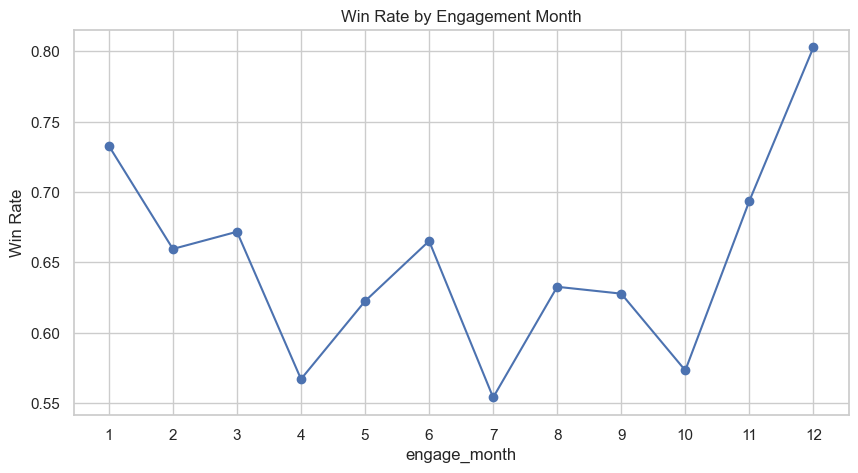

In [5]:
month_win = df.groupby('engage_month')['target'].mean()

plt.figure(figsize=(10, 5))
month_win.plot(marker='o')
plt.title("Win Rate by Engagement Month")
plt.ylabel("Win Rate")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

## 5. Agent Performance
Who are the "Closers"?

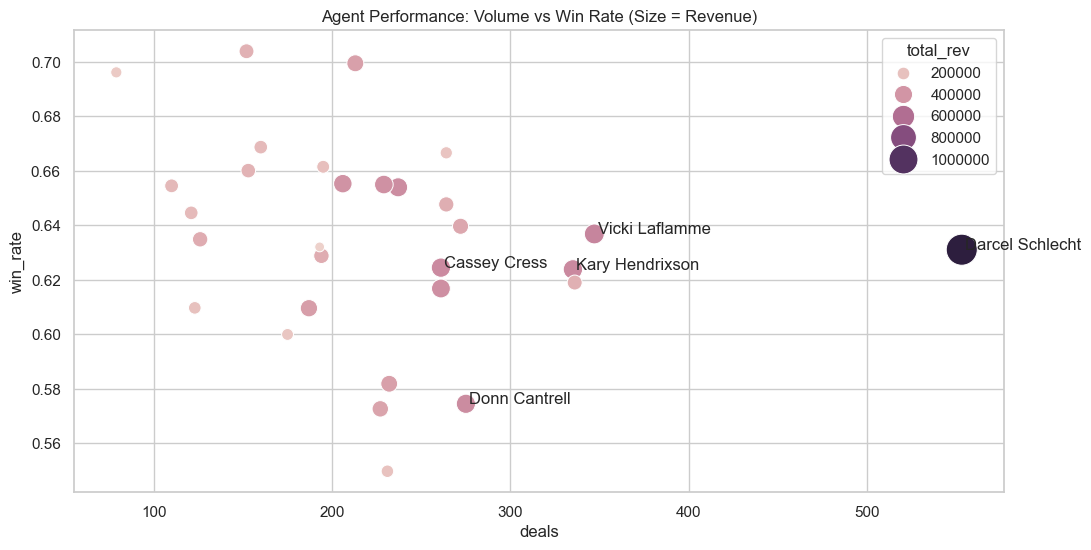

,deals,wins,win_rate,total_rev
sales_agent,,,,
Darcel Schlecht,553,349,0.631103,1153214.0
Vicki Laflamme,347,221,0.636888,478396.0
Kary Hendrixson,335,209,0.623881,454298.0
Cassey Cress,261,163,0.624521,450489.0
Donn Cantrell,275,158,0.574545,445860.0
Reed Clapper,237,155,0.654008,438336.0
Zane Levy,261,161,0.616858,430068.0
Corliss Cosme,229,150,0.655022,421036.0
James Ascencio,206,135,0.655340,413533.0


In [6]:
agent_perf = df.groupby('sales_agent').agg(
    deals=('target', 'count'),
    wins=('target', 'sum'),
    win_rate=('target', 'mean'),
    total_rev=('close_value', 'sum')
).sort_values('total_rev', ascending=False)

plt.figure(figsize=(12, 6))
sns.scatterplot(data=agent_perf, x='deals', y='win_rate', size='total_rev', hue='total_rev', sizes=(50, 500))
plt.title("Agent Performance: Volume vs Win Rate (Size = Revenue)")
# Label top 5 agents
for i in range(5):
    plt.text(agent_perf.iloc[i]['deals']+2, agent_perf.iloc[i]['win_rate'], agent_perf.index[i])
plt.show()

agent_perf.head(10)

## 6. Skewness Analysis
Analyze skewness in numeric features to understand data distribution.

In [ ]:
from scipy.stats import skew

# Load raw data for skewness analysis on original values
accounts = pd.read_csv("../data/raw/accounts.csv")
products = pd.read_csv("../data/raw/products.csv")
pipeline = pd.read_csv("../data/raw/sales_pipeline.csv")
sales_teams = pd.read_csv("../data/raw/sales_teams.csv")

# Create master_df
pipeline_final = pipeline[pipeline['deal_stage'].isin(['Won', 'Lost'])].copy()
pipeline_final['target'] = pipeline_final['deal_stage'].map({'Won': 1, 'Lost': 0})

master_df = pipeline_final.merge(accounts, how='left', on='account')
master_df = master_df.merge(products, how='left', on='product')
master_df = master_df.merge(sales_teams, how='left', on='sales_agent')

master_df['engage_date'] = pd.to_datetime(master_df['engage_date'])
master_df['close_date'] = pd.to_datetime(master_df['close_date'])
master_df['deal_duration_days'] = (master_df['close_date'] - master_df['engage_date']).dt.days

numeric_features = [
    'close_value',
    'revenue',
    'employees',
    'deal_duration_days'
]

for col in numeric_features:
    print(f"{col} skewness:", skew(master_df[col]))

## 7. Class Imbalance Ratio
Calculate the imbalance ratio between Won and Lost deals.

In [ ]:
class_counts = df['target'].value_counts(normalize=True)
print(class_counts)

imbalance_ratio = class_counts[1] / class_counts[0]
print("Imbalance ratio (Won/Lost):", imbalance_ratio)

## 8. Correlation Analysis with Target
Find which numeric features correlate most with the target variable.

In [ ]:
numeric_cols = df.select_dtypes(exclude='object').columns.tolist()
corr_df = df[numeric_cols].corr()

corr_df['target'].sort_values(ascending=False)

## 9. Categorical Features Cardinality
Count unique values in categorical features.

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    print(col, df[col].nunique())

## 10. Deal Duration by Outcome
Visualize deal duration differences between Won and Lost deals.

In [ ]:
sns.boxplot(x='target', y='deal_duration_days', data=df)
plt.title("Deal Duration by Outcome (0=Lost, 1=Won)")
plt.show()